# Rolling Cointegration Test - Demonstration

This notebook demonstrates the `rolling_coint` function, which performs rolling window Engle-Granger cointegration tests.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from rolling_coint import rolling_coint, plot_rolling_coint_results
from statsmodels.tsa.stattools import coint

np.random.seed(42)

## Example 1: Cointegrated Series

Create two cointegrated I(1) series where y1 = y0 + noise


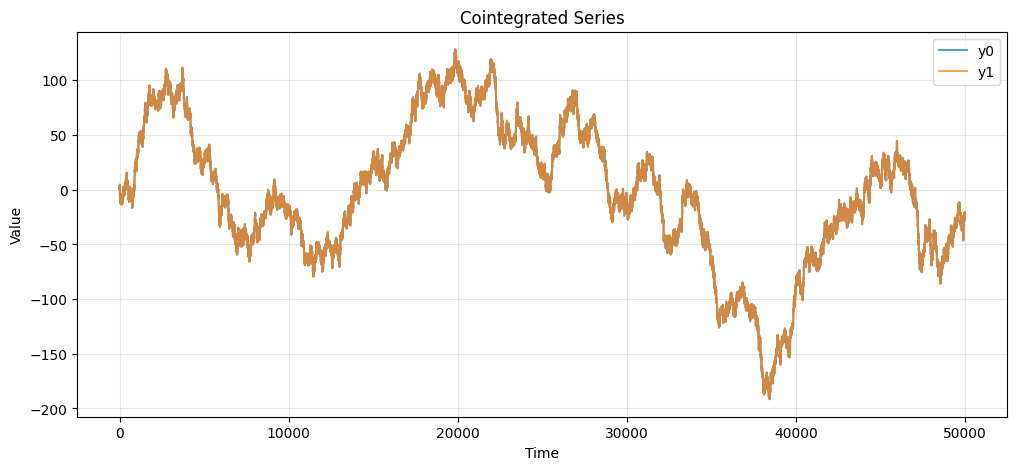

Static Cointegration Test:
  Test Statistic: -223.0777
  P-value: 0.0000
  Critical Values: [-3.89665906 -3.33625221 -3.04453483]


In [16]:
# Generate cointegrated series
n = 50000
y0 = np.cumsum(np.random.randn(n))  # Random walk
y1 = y0 + np.random.randn(n) * 0.5  # Cointegrated with y0

# Plot the series
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y0, label="y0", alpha=0.7)
ax.plot(y1, label="y1", alpha=0.7)
ax.set_title("Cointegrated Series")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Static cointegration test
static_result = coint(y0, y1)
print("Static Cointegration Test:")
print(f"  Test Statistic: {static_result[0]:.4f}")
print(f"  P-value: {static_result[1]:.4f}")
print(f"  Critical Values: {static_result[2]}")

RollingCointegrationResults(
  n_valid_windows=49001,
  usedlag=2,
  mean_t_stat=-18.1038,
  mean_pvalue=0.0000
)


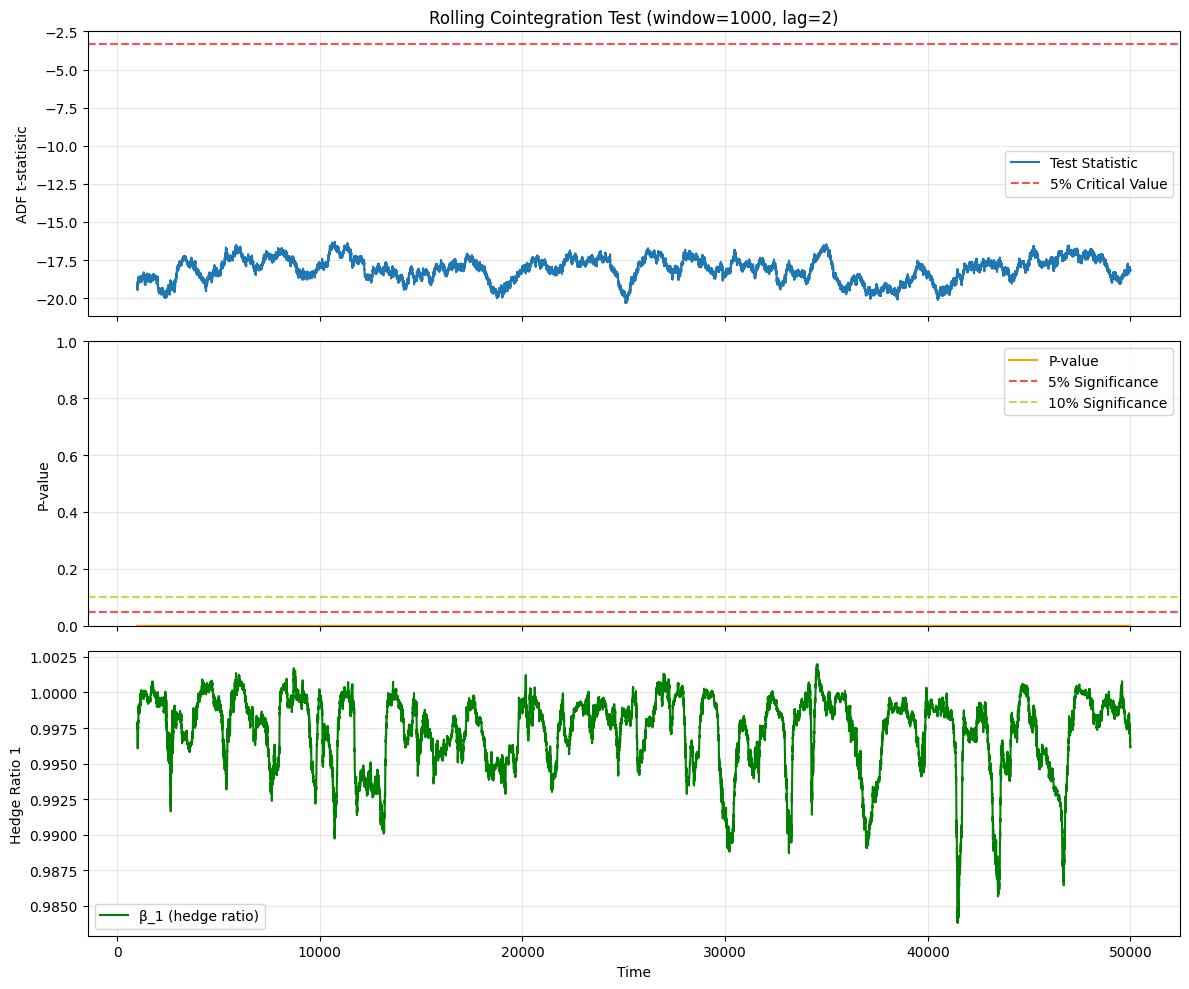

In [17]:
# Rolling cointegration test
# Using fixed lag=2 for efficient rolling computation (no autolag loop)
window = 1000
results = rolling_coint(
    y0=y0,
    y1=y1,
    window=window,
    trend="c",
    method="inv",
    lag=2,  # Fixed lag for ADF - enables efficient rolling OLS
)

print(results)

# Plot results
fig, axes = plot_rolling_coint_results(
    results,
    title=f"Rolling Cointegration Test (window={window}, lag={results.usedlag})",
)
plt.show()

## Validation: Compare Against statsmodels.coint()

Verify that our rolling implementation produces the same results as calling `coint()` in a loop over windows.


In [18]:
import time

# Use the same data from above (y0, y1 with n=500, window=100)
lag = 2

# Our rolling implementation
start = time.time()
results_rolling = rolling_coint(y0, y1, window=window, trend="c", lag=lag)
time_rolling = time.time() - start
print(f"Rolling implementation: {time_rolling:.3f}s")

# Reference: call coint() in a loop over windows
start = time.time()
coint_t_stats = np.full(n, np.nan)
coint_pvalues = np.full(n, np.nan)

for i in range(window, n + 1):
    y0_win = y0[i - window : i]
    y1_win = y1[i - window : i]
    try:
        result = coint(y0_win, y1_win, trend="c", maxlag=lag, autolag=None)
        coint_t_stats[i - 1] = result[0]
        coint_pvalues[i - 1] = result[1]
    except Exception as e:
        print(f"Window {i}: {e}")

time_loop = time.time() - start
print(f"Loop coint() implementation: {time_loop:.3f}s")
print(f"\nSpeedup: {time_loop / time_rolling:.1f}x faster")

Rolling implementation: 21.726s
Loop coint() implementation: 71.614s

Speedup: 3.3x faster


Number of valid windows: 49001

--- Test Statistics Comparison ---
Correlation: 1.000000
Max absolute difference: 0.000000
Mean absolute difference: 0.000000


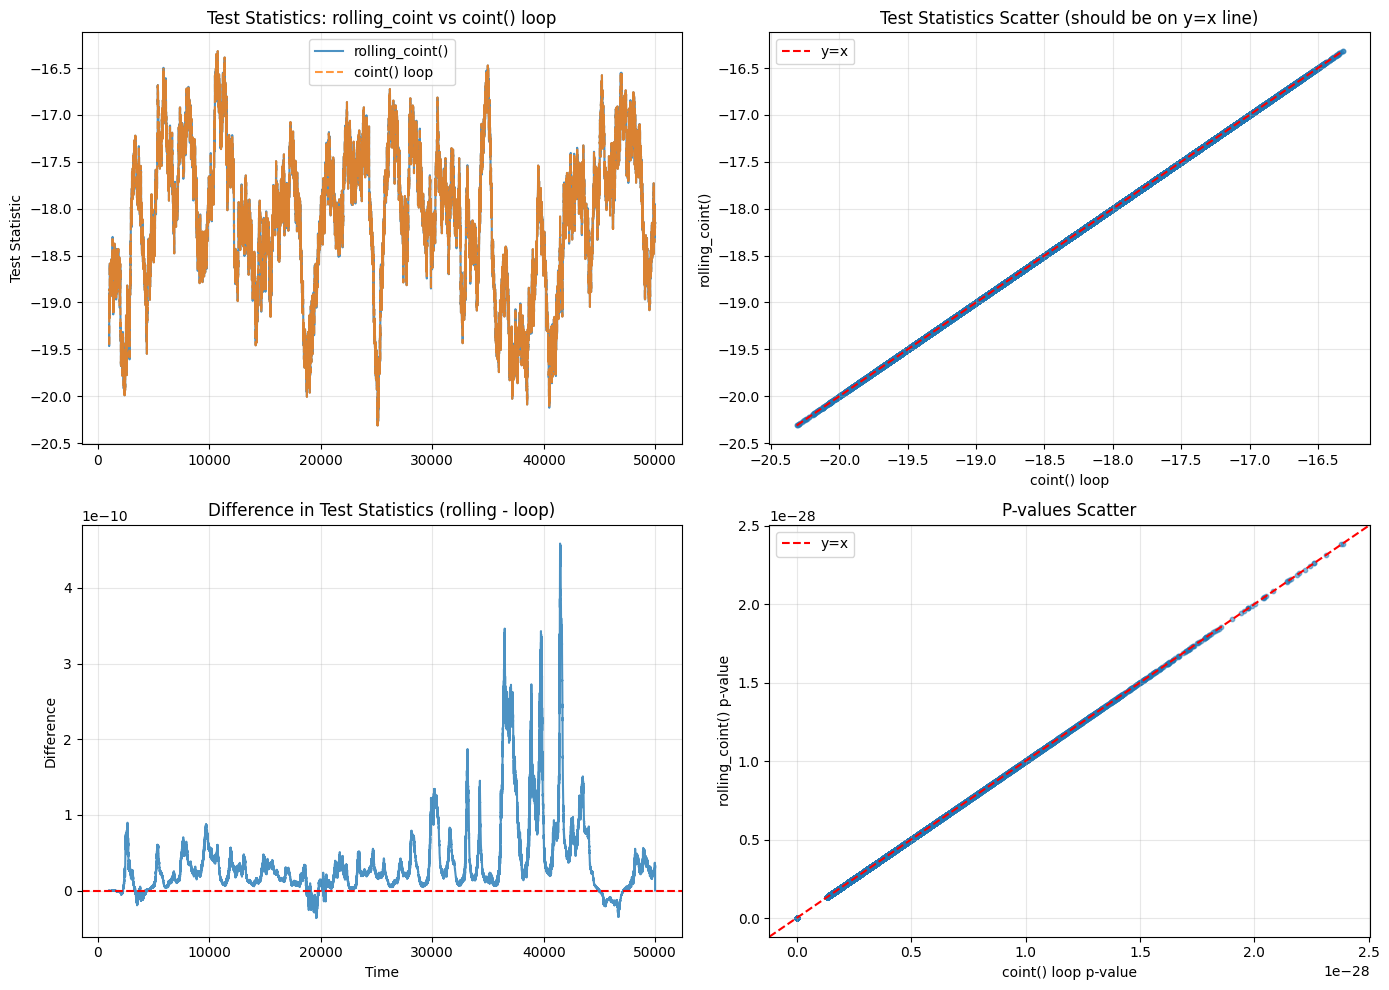


--- P-values Comparison ---
Correlation: 1.000000
Max absolute difference: 0.000000


In [19]:
# Compare the values
valid = ~np.isnan(results_rolling.coint_t) & ~np.isnan(coint_t_stats)
rolling_valid = results_rolling.coint_t[valid]
coint_valid = coint_t_stats[valid]

print(f"Number of valid windows: {valid.sum()}")
print("\n--- Test Statistics Comparison ---")
print(f"Correlation: {np.corrcoef(rolling_valid, coint_valid)[0, 1]:.6f}")
print(f"Max absolute difference: {np.max(np.abs(rolling_valid - coint_valid)):.6f}")
print(f"Mean absolute difference: {np.mean(np.abs(rolling_valid - coint_valid)):.6f}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Test statistics overlay
axes[0, 0].plot(results_rolling.coint_t, label="rolling_coint()", alpha=0.8)
axes[0, 0].plot(coint_t_stats, label="coint() loop", alpha=0.8, linestyle="--")
axes[0, 0].set_ylabel("Test Statistic")
axes[0, 0].set_title("Test Statistics: rolling_coint vs coint() loop")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot of test statistics
axes[0, 1].scatter(coint_valid, rolling_valid, alpha=0.5, s=10)
axes[0, 1].plot(
    [coint_valid.min(), coint_valid.max()],
    [coint_valid.min(), coint_valid.max()],
    "r--",
    label="y=x",
)
axes[0, 1].set_xlabel("coint() loop")
axes[0, 1].set_ylabel("rolling_coint()")
axes[0, 1].set_title("Test Statistics Scatter (should be on y=x line)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Difference in test statistics
diff = results_rolling.coint_t - coint_t_stats
axes[1, 0].plot(diff, alpha=0.8)
axes[1, 0].axhline(y=0, color="r", linestyle="--")
axes[1, 0].set_ylabel("Difference")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_title("Difference in Test Statistics (rolling - loop)")
axes[1, 0].grid(True, alpha=0.3)

# P-values comparison
rolling_pval = results_rolling.pvalue[valid]
coint_pval = coint_pvalues[valid]
axes[1, 1].scatter(coint_pval, rolling_pval, alpha=0.5, s=10)
# Set axis limits relative to actual data with some padding
pval_min = min(rolling_pval.min(), coint_pval.min())
pval_max = max(rolling_pval.max(), coint_pval.max())
pval_range = pval_max - pval_min
pval_pad = pval_range * 0.05
axes[1, 1].plot(
    [pval_min - pval_pad, pval_max + pval_pad],
    [pval_min - pval_pad, pval_max + pval_pad],
    "r--",
    label="y=x",
)
axes[1, 1].set_xlim(pval_min - pval_pad, pval_max + pval_pad)
axes[1, 1].set_ylim(pval_min - pval_pad, pval_max + pval_pad)
axes[1, 1].set_xlabel("coint() loop p-value")
axes[1, 1].set_ylabel("rolling_coint() p-value")
axes[1, 1].set_title("P-values Scatter")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- P-values Comparison ---")
print(f"Correlation: {np.corrcoef(rolling_pval, coint_pval)[0, 1]:.6f}")
print(f"Max absolute difference: {np.max(np.abs(rolling_pval - coint_pval)):.6f}")